In [1]:
import sys
print(sys.executable)

c:\Users\Rashi\Desktop\Breast-Cancer-Biomarker-Discovery\venv\Scripts\python.exe


In [2]:
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [3]:
gse = GEOparse.get_GEO(
    geo="GSE42568",
    destdir="../data",
    silent=False
)

print("Dataset loaded successfully")

13-Sep-2026 16:55:28 DEBUG utils - Directory ../data already exists. Skipping.
13-Sep-2026 16:55:28 INFO GEOparse - File already exist: using local version.
13-Sep-2026 16:55:28 INFO GEOparse - Parsing ../data\GSE42568_family.soft.gz: 
13-Sep-2026 16:55:28 DEBUG GEOparse - DATABASE: GeoMiame
13-Sep-2026 16:55:28 DEBUG GEOparse - SERIES: GSE42568
13-Sep-2026 16:55:28 DEBUG GEOparse - PLATFORM: GPL570
c:\Users\Rashi\Desktop\Breast-Cancer-Biomarker-Discovery\venv\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
13-Sep-2026 16:55:58 DEBUG GEOparse - SAMPLE: GSM1045191
13-Sep-2026 16:56:00 DEBUG GEOparse - SAMPLE: GSM1045192
13-Sep-2026 16:56:02 DEBUG GEOparse - SAMPLE: GSM1045193
13-Sep-2026 16:56:04 DEBUG GEOparse - SAMPLE: GSM1045194
13-Sep-2026 16:56:05 DEBUG GEOparse - SAMPLE: GSM1045195
13-Sep-2026 16:56:07 DEBUG GEOparse -

Dataset loaded successfully


In [4]:
print("Number of samples:", len(gse.gsms))

Number of samples: 121


In [5]:
list(gse.gsms.keys())[:10]

['GSM1045191',
 'GSM1045192',
 'GSM1045193',
 'GSM1045194',
 'GSM1045195',
 'GSM1045196',
 'GSM1045197',
 'GSM1045198',
 'GSM1045199',
 'GSM1045200']

In [6]:
sample = gse.gsms['GSM1045191']

sample.metadata.keys()

dict_keys(['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'treatment_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count'])

In [7]:
sample.metadata


{'title': ['Normal breast, N1_15_12_04'],
 'geo_accession': ['GSM1045191'],
 'status': ['Public on May 26 2013'],
 'submission_date': ['Nov 27 2012'],
 'last_update_date': ['Jul 30 2013'],
 'type': ['RNA'],
 'channel_count': ['1'],
 'source_name_ch1': ['Breast tissue, normal'],
 'organism_ch1': ['Homo sapiens'],
 'taxid_ch1': ['9606'],
 'characteristics_ch1': ['tissue: normal breast',
  'age: NA',
  'er_status: NA',
  'size: NA',
  'grade: NA',
  'lymph node status: NA',
  'relapse free survival time_days: NA',
  'relapse free survival event: NA',
  'overall survival time_days: NA',
  'overall survival event: NA'],
 'treatment_protocol_ch1': ['Tissues were stored at -70Â°C/-80Â°C prior to RNA isolation.'],
 'molecule_ch1': ['total RNA'],
 'extract_protocol_ch1': ["Samples were homogenised, on ice, in 1 ml TriReagent (Sigma; Poole, UK) and total RNA was subsequently isolated according to the manufacturer's instructions. RNA quantity and purity were assessed at 260 nm and 280 nm using a 

In [8]:
sample_info = []

for gsm_id, gsm in gse.gsms.items():
    sample_info.append({
        "sample_id": gsm_id,
        "title": gsm.metadata["title"][0],
        "source": gsm.metadata["source_name_ch1"][0],
        "characteristics": gsm.metadata["characteristics_ch1"][0]
    })

sample_metadata = pd.DataFrame(sample_info)

sample_metadata.head()

,sample_id,title,source,characteristics
0,GSM1045191,"Normal breast, N1_15_12_04","Breast tissue, normal",tissue: normal breast
1,GSM1045192,"Normal breast, N4_14_12_04","Breast tissue, normal",tissue: normal breast
2,GSM1045193,"Normal breast, N5_15_12_04","Breast tissue, normal",tissue: normal breast
3,GSM1045194,"Normal breast, N6_14_12_04","Breast tissue, normal",tissue: normal breast
4,GSM1045195,"Normal breast, P1_15_12_04","Breast tissue, normal",tissue: normal breast


In [9]:
sample_metadata["source"].value_counts()

source
Breast tissue, cancer    104
Breast tissue, normal     17
Name: count, dtype: int64

In [10]:
expression_tables = []

for gsm_id, gsm in gse.gsms.items():
    table = gsm.table.copy()
    table["sample_id"] = gsm_id
    expression_tables.append(table)

expression_data = pd.concat(expression_tables)

expression_data.head()

,ID_REF,VALUE,sample_id
0,1007_s_at,5.640239,GSM1045191
1,1053_at,5.074866,GSM1045191
2,117_at,4.191770,GSM1045191
3,121_at,3.574706,GSM1045191
4,1255_g_at,2.312812,GSM1045191


In [11]:
expression_data.shape

(6615675, 3)

In [12]:
expression_matrix = expression_data.pivot_table(
    index="ID_REF",
    columns="sample_id",
    values="VALUE"
)

expression_matrix.head()

sample_id,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,GSM1045200,...,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.640239,3.557696,3.132007,6.865108,4.955184,5.573674,4.714100,5.234298,5.050853,6.913114,...,6.953623,7.007825,7.867141,8.436528,6.020774,7.168925,7.935322,6.937005,8.822155,7.834706
1053_at,5.074866,4.984593,5.109481,5.473609,5.348400,5.572707,5.675239,5.792026,6.185706,5.230088,...,5.453186,5.572707,5.471505,6.830667,6.855478,5.358832,4.804079,5.488895,5.575357,5.687899
117_at,4.191770,4.269061,4.131843,3.616546,4.296657,4.184048,4.000772,4.984939,4.958126,3.554531,...,4.209247,3.946714,5.186979,3.888039,4.131843,4.131843,3.967933,4.392234,4.269244,4.264560
121_at,3.574706,4.065623,3.574706,3.574706,3.799293,3.803312,3.643243,4.053245,3.574706,3.580369,...,3.574706,3.574706,3.574706,3.574706,3.574706,3.502410,3.574706,3.579242,3.574706,3.574706
1255_g_at,2.312812,2.409371,2.312812,2.312812,2.349630,2.312812,2.312812,2.312812,2.312812,2.312812,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812,2.312812


In [13]:
expression_matrix.shape

(54675, 121)

In [14]:
expression_matrix.to_csv(
    "../data/breast_cancer_expression_matrix.csv"
)

print("Expression matrix saved")

Expression matrix saved


In [15]:
sample_metadata.head()

,sample_id,title,source,characteristics
0,GSM1045191,"Normal breast, N1_15_12_04","Breast tissue, normal",tissue: normal breast
1,GSM1045192,"Normal breast, N4_14_12_04","Breast tissue, normal",tissue: normal breast
2,GSM1045193,"Normal breast, N5_15_12_04","Breast tissue, normal",tissue: normal breast
3,GSM1045194,"Normal breast, N6_14_12_04","Breast tissue, normal",tissue: normal breast
4,GSM1045195,"Normal breast, P1_15_12_04","Breast tissue, normal",tissue: normal breast


In [16]:
sample_metadata["source"].value_counts()

source
Breast tissue, cancer    104
Breast tissue, normal     17
Name: count, dtype: int64

In [18]:
normal_samples = sample_metadata[
    sample_metadata["source"]=="Breast tissue, normal"
]["sample_id"].tolist()


cancer_samples = sample_metadata[
    sample_metadata["source"]=="Breast tissue, cancer"
]["sample_id"].tolist()

In [19]:
len(normal_samples), len(cancer_samples)

(17, 104)

In [20]:
expression_matrix.shape

(54675, 121)

In [21]:
# Separate expression data into two groups

normal_expression = expression_matrix[normal_samples]

cancer_expression = expression_matrix[cancer_samples]


# Create results table

results = pd.DataFrame(index=expression_matrix.index)


# Calculate average expression for each gene

results["normal_mean"] = normal_expression.mean(axis=1)

results["cancer_mean"] = cancer_expression.mean(axis=1)


# Calculate difference

results["difference"] = (
    results["cancer_mean"] -
    results["normal_mean"]
)


results.head()

,normal_mean,cancer_mean,difference
ID_REF,,,
1007_s_at,5.143417,7.521487,2.378070
1053_at,5.491319,5.686114,0.194795
117_at,4.215687,4.478162,0.262474
121_at,3.721981,3.669668,-0.052313
1255_g_at,2.320657,2.315915,-0.004742


In [22]:
top_upregulated = results.sort_values(
    by="difference",
    ascending=False
)

top_upregulated.head(20)

,normal_mean,cancer_mean,difference
ID_REF,,,
201650_at,6.287653,11.739673,5.452020
37892_at,3.601280,8.978260,5.376979
232165_at,3.840829,9.124154,5.283325
201839_s_at,6.767673,11.924118,5.156445
232164_s_at,4.175217,9.211906,5.036688
200606_at,5.497521,10.475321,4.977801
204320_at,3.319726,8.261706,4.941980
201596_x_at,6.045157,10.968937,4.923781
225846_at,4.276231,9.171065,4.894834


In [23]:
top_downregulated = results.sort_values(
    by="difference",
    ascending=True
)

top_downregulated.head(20)

,normal_mean,cancer_mean,difference
ID_REF,,,
235978_at,11.621737,3.983014,-7.638723
207092_at,11.937041,4.583179,-7.353862
219140_s_at,11.009412,3.933553,-7.075860
209612_s_at,11.863514,5.218610,-6.644904
209613_s_at,11.832516,5.361822,-6.470694
203548_s_at,11.699882,5.240446,-6.459436
209555_s_at,12.137147,5.678954,-6.458193
205913_at,10.451545,4.056804,-6.394741
203980_at,12.887326,6.521125,-6.366201


In [24]:
from scipy.stats import ttest_ind

In [25]:
p_values = []

for gene in expression_matrix.index:
    
    normal_values = normal_expression.loc[gene]
    cancer_values = cancer_expression.loc[gene]
    
    stat, p = ttest_ind(
        cancer_values,
        normal_values
    )
    
    p_values.append(p)


results["p_value"] = p_values

results.head()

c:\Users\Rashi\Desktop\Breast-Cancer-Biomarker-Discovery\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,normal_mean,cancer_mean,difference,p_value
ID_REF,,,,
1007_s_at,5.143417,7.521487,2.378070,1.054656e-14
1053_at,5.491319,5.686114,0.194795,3.413857e-01
117_at,4.215687,4.478162,0.262474,1.749951e-01
121_at,3.721981,3.669668,-0.052313,5.750617e-01
1255_g_at,2.320657,2.315915,-0.004742,3.953547e-01


In [27]:
results.head()

,normal_mean,cancer_mean,difference,p_value
ID_REF,,,,
1007_s_at,5.143417,7.521487,2.378070,1.054656e-14
1053_at,5.491319,5.686114,0.194795,3.413857e-01
117_at,4.215687,4.478162,0.262474,1.749951e-01
121_at,3.721981,3.669668,-0.052313,5.750617e-01
1255_g_at,2.320657,2.315915,-0.004742,3.953547e-01


In [28]:
pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.3 MB 4.1 MB/s eta 0:00:03
   --- ------------------------------------ 1.0/11.3 MB 12.2 MB/s eta 0:00:01
   ------- -------------------------------- 2.1/11.3 MB 18.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.9/11.3 MB 18.4 MB/s eta 0:00:01
   -------------- ------------------------- 4.1/11.3 MB 20.0 MB/s eta 0:00:01
   ----------------- ---------------------- 5.0/11.3 MB 21.4 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.3 MB 22.3 MB/s eta 0:00:01
   -------------------------- ------------- 7.4/11.3 MB 22.4 MB/s eta 0:00:01
   ----------------------------- ---------- 8.5/11.3 MB 23.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.3 MB 23.8 MB/s eta 0:00:01
   ------------------------------------- -- 10.6/11.3 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 25.2 MB/s eta 0


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from statsmodels.stats.multitest import multipletests

print("Statsmodels loaded successfully")

Statsmodels loaded successfully


In [30]:
# Multiple testing correction using Benjamini-Hochberg FDR

adjusted_results = multipletests(
    results["p_value"],
    method="fdr_bh"
)

results["adjusted_p_value"] = adjusted_results[1]

results.head()

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value
ID_REF,,,,,
1007_s_at,5.143417,7.521487,2.378070,1.054656e-14,NaN
1053_at,5.491319,5.686114,0.194795,3.413857e-01,NaN
117_at,4.215687,4.478162,0.262474,1.749951e-01,NaN
121_at,3.721981,3.669668,-0.052313,5.750617e-01,NaN
1255_g_at,2.320657,2.315915,-0.004742,3.953547e-01,NaN


In [31]:
significant_genes = results[
    (results["adjusted_p_value"] < 0.05) &
    (abs(results["difference"]) > 1)
]

print(
    "Number of significant genes:",
    significant_genes.shape[0]
)

significant_genes.head()

Number of significant genes: 0


,normal_mean,cancer_mean,difference,p_value,adjusted_p_value
ID_REF,,,,,


In [35]:
results["p_value"].min()

np.float64(3.027006058279021e-42)

In [36]:
results["adjusted_p_value"].min()

np.float64(nan)

In [37]:
results["p_value"].isna().sum()

np.int64(96)

In [38]:
# Remove genes with missing p-values before FDR correction

results_clean = results.dropna(subset=["p_value"]).copy()

print("Original genes:", results.shape[0])
print("Genes after removing missing p-values:", results_clean.shape[0])

Original genes: 54675
Genes after removing missing p-values: 54579


In [39]:
from statsmodels.stats.multitest import multipletests

adjusted_results = multipletests(
    results_clean["p_value"],
    method="fdr_bh"
)

results_clean["adjusted_p_value"] = adjusted_results[1]

results_clean.head()

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value
ID_REF,,,,,
1007_s_at,5.143417,7.521487,2.378070,1.054656e-14,4.380676e-13
1053_at,5.491319,5.686114,0.194795,3.413857e-01,5.336529e-01
117_at,4.215687,4.478162,0.262474,1.749951e-01,3.343506e-01
121_at,3.721981,3.669668,-0.052313,5.750617e-01,7.330506e-01
1255_g_at,2.320657,2.315915,-0.004742,3.953547e-01,5.868069e-01


In [40]:
significant_genes = results_clean[
    (results_clean["adjusted_p_value"] < 0.05) &
    (abs(results_clean["difference"]) > 1)
]

print(
    "Number of significant genes:",
    significant_genes.shape[0]
)

Number of significant genes: 6468


In [41]:
significant_genes.to_csv(
    "../results/significant_breast_cancer_genes.csv"
)

print("Significant genes saved")

Significant genes saved


In [42]:
top_upregulated = significant_genes.sort_values(
    by="difference",
    ascending=False
)

top_upregulated.head(20)

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value
ID_REF,,,,,
201650_at,6.287653,11.739673,5.452020,2.395358e-16,1.279220e-14
37892_at,3.601280,8.978260,5.376979,1.907838e-14,7.656464e-13
232165_at,3.840829,9.124154,5.283325,2.006711e-19,1.803608e-17
201839_s_at,6.767673,11.924118,5.156445,4.143762e-22,5.843990e-20
232164_s_at,4.175217,9.211906,5.036688,3.817545e-18,2.785532e-16
200606_at,5.497521,10.475321,4.977801,6.390504e-27,1.855252e-24
204320_at,3.319726,8.261706,4.941980,2.867488e-14,1.123508e-12
201596_x_at,6.045157,10.968937,4.923781,1.260836e-19,1.176328e-17
225846_at,4.276231,9.171065,4.894834,1.002664e-25,2.379321e-23


In [43]:
top_downregulated = significant_genes.sort_values(
    by="difference",
    ascending=True
)

top_downregulated.head(20)

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value
ID_REF,,,,,
235978_at,11.621737,3.983014,-7.638723,2.971492e-25,6.461398e-23
207092_at,11.937041,4.583179,-7.353862,4.580811e-22,6.361732e-20
219140_s_at,11.009412,3.933553,-7.075860,1.250439e-24,2.527693e-22
209612_s_at,11.863514,5.218610,-6.644904,8.114484e-19,6.710310e-17
209613_s_at,11.832516,5.361822,-6.470694,1.186273e-15,5.689420e-14
203548_s_at,11.699882,5.240446,-6.459436,4.234751e-19,3.617034e-17
209555_s_at,12.137147,5.678954,-6.458193,1.870221e-16,1.015669e-14
205913_at,10.451545,4.056804,-6.394741,7.797928e-20,7.440613e-18
203980_at,12.887326,6.521125,-6.366201,1.932257e-13,6.607810e-12


In [44]:
gse.gpls.keys()

dict_keys(['GPL570'])

In [45]:
platform = gse.gpls['GPL570']

platform.table.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [46]:
# Extract annotation information

annotation = platform.table[
    [
        "ID",
        "Gene Symbol",
        "Gene Title",
        "Gene Ontology Biological Process",
        "Gene Ontology Molecular Function"
    ]
]

annotation.head()

,ID,Gene Symbol,Gene Title,Gene Ontology Biological Process,Gene Ontology Molecular Function
0,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,0001558 // regulation of cell growth // inferr...,0000166 // nucleotide binding // inferred from...
1,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa",0000278 // mitotic cell cycle // traceable aut...,0000166 // nucleotide binding // inferred from...
2,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B'),0000902 // cell morphogenesis // inferred from...,0000166 // nucleotide binding // inferred from...
3,121_at,PAX8,paired box 8,0001655 // urogenital system development // in...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina),0007165 // signal transduction // non-traceabl...,0005509 // calcium ion binding // inferred fro...


In [47]:
annotated_results = results_clean.merge(
    annotation,
    left_on="ID_REF",
    right_on="ID",
    how="left"
)

annotated_results.head()

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value,ID,Gene Symbol,Gene Title,Gene Ontology Biological Process,Gene Ontology Molecular Function
0,5.143417,7.521487,2.378070,1.054656e-14,4.380676e-13,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,0001558 // regulation of cell growth // inferr...,0000166 // nucleotide binding // inferred from...
1,5.491319,5.686114,0.194795,3.413857e-01,5.336529e-01,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa",0000278 // mitotic cell cycle // traceable aut...,0000166 // nucleotide binding // inferred from...
2,4.215687,4.478162,0.262474,1.749951e-01,3.343506e-01,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B'),0000902 // cell morphogenesis // inferred from...,0000166 // nucleotide binding // inferred from...
3,3.721981,3.669668,-0.052313,5.750617e-01,7.330506e-01,121_at,PAX8,paired box 8,0001655 // urogenital system development // in...,0000979 // RNA polymerase II core promoter seq...
4,2.320657,2.315915,-0.004742,3.953547e-01,5.868069e-01,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina),0007165 // signal transduction // non-traceabl...,0005509 // calcium ion binding // inferred fro...


In [48]:
final_biomarker_table = annotated_results[
    [
        "Gene Symbol",
        "Gene Title",
        "difference",
        "p_value",
        "adjusted_p_value",
        "Gene Ontology Biological Process"
    ]
]

final_biomarker_table.head()

,Gene Symbol,Gene Title,difference,p_value,adjusted_p_value,Gene Ontology Biological Process
0,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,2.378070,1.054656e-14,4.380676e-13,0001558 // regulation of cell growth // inferr...
1,RFC2,"replication factor C (activator 1) 2, 40kDa",0.194795,3.413857e-01,5.336529e-01,0000278 // mitotic cell cycle // traceable aut...
2,HSPA6,heat shock 70kDa protein 6 (HSP70B'),0.262474,1.749951e-01,3.343506e-01,0000902 // cell morphogenesis // inferred from...
3,PAX8,paired box 8,-0.052313,5.750617e-01,7.330506e-01,0001655 // urogenital system development // in...
4,GUCA1A,guanylate cyclase activator 1A (retina),-0.004742,3.953547e-01,5.868069e-01,0007165 // signal transduction // non-traceabl...


In [49]:
final_biomarker_table.to_csv(
    "../results/annotated_biomarker_candidates.csv",
    index=False
)

print("Annotated biomarker table saved")

Annotated biomarker table saved


In [50]:
# Merge only significant genes with annotation

significant_annotated = significant_genes.reset_index().merge(
    annotation,
    left_on="ID_REF",
    right_on="ID",
    how="left"
)

significant_annotated.head()

,ID_REF,normal_mean,cancer_mean,difference,p_value,adjusted_p_value,ID,Gene Symbol,Gene Title,Gene Ontology Biological Process,Gene Ontology Molecular Function
0,1007_s_at,5.143417,7.521487,2.378070,1.054656e-14,4.380676e-13,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,0001558 // regulation of cell growth // inferr...,0000166 // nucleotide binding // inferred from...
1,1552257_a_at,5.755460,7.229760,1.474300,4.417194e-07,4.789155e-06,1552257_a_at,TTLL12,"tubulin tyrosine ligase-like family, member 12",0006464 // cellular protein modification proce...,NaN
2,1552287_s_at,4.448450,5.839163,1.390712,8.072357e-09,1.222818e-07,1552287_s_at,AFG3L1P,"AFG3-like AAA ATPase 1, pseudogene",0006508 // proteolysis // inferred from electr...,0004222 // metalloendopeptidase activity // in...
3,1552309_a_at,5.806621,3.772645,-2.033976,1.899750e-13,6.508881e-12,1552309_a_at,NEXN,nexilin (F actin binding protein),0006468 // protein phosphorylation // not reco...,0003779 // actin binding // inferred from elec...
4,1552310_at,6.906120,5.709468,-1.196652,7.535801e-06,6.292786e-05,1552310_at,C15orf40,chromosome 15 open reading frame 40,NaN,NaN


In [51]:
upregulated_annotated = significant_annotated[
    significant_annotated["difference"] > 1
].sort_values(
    by="difference",
    ascending=False
)

upregulated_annotated.head(20)

,ID_REF,normal_mean,cancer_mean,difference,p_value,adjusted_p_value,ID,Gene Symbol,Gene Title,Gene Ontology Biological Process,Gene Ontology Molecular Function
604,201650_at,6.287653,11.739673,5.452020,2.395358e-16,1.279220e-14,201650_at,KRT19,keratin 19,0016032 // viral process // inferred from elec...,0005198 // structural molecule activity // inf...
6402,37892_at,3.601280,8.978260,5.376979,1.907838e-14,7.656464e-13,37892_at,COL11A1,"collagen, type XI, alpha 1",0001502 // cartilage condensation // inferred ...,0005201 // extracellular matrix structural con...
5240,232165_at,3.840829,9.124154,5.283325,2.006711e-19,1.803608e-17,232165_at,EPPK1,epiplakin 1,NaN,0044822 // poly(A) RNA binding // inferred fro...
647,201839_s_at,6.767673,11.924118,5.156445,4.143762e-22,5.843990e-20,201839_s_at,EPCAM,epithelial cell adhesion molecule,0001657 // ureteric bud development // inferre...,0005515 // protein binding // inferred from ph...
5239,232164_s_at,4.175217,9.211906,5.036688,3.817545e-18,2.785532e-16,232164_s_at,EPPK1,epiplakin 1,NaN,0044822 // poly(A) RNA binding // inferred fro...
391,200606_at,5.497521,10.475321,4.977801,6.390504e-27,1.855252e-24,200606_at,DSP,desmoplakin,0002934 // desmosome organization // inferred ...,0005080 // protein kinase C binding // inferre...
1234,204320_at,3.319726,8.261706,4.941980,2.867488e-14,1.123508e-12,204320_at,COL11A1,"collagen, type XI, alpha 1",0001502 // cartilage condensation // inferred ...,0005201 // extracellular matrix structural con...
594,201596_x_at,6.045157,10.968937,4.923781,1.260836e-19,1.176328e-17,201596_x_at,KRT18,keratin 18,0006915 // apoptotic process // inferred from ...,0005198 // structural molecule activity // inf...
4190,225846_at,4.276231,9.171065,4.894834,1.002664e-25,2.379321e-23,225846_at,ESRP1,epithelial splicing regulatory protein 1,0006397 // mRNA processing // inferred from el...,0000166 // nucleotide binding // inferred from...
487,201131_s_at,6.035072,10.926179,4.891107,1.433452e-19,1.323796e-17,201131_s_at,CDH1,"cadherin 1, type 1, E-cadherin (epithelial)",0001701 // in utero embryonic development // i...,0001948 // glycoprotein binding // inferred fr...


In [52]:
downregulated_annotated = significant_annotated[
    significant_annotated["difference"] < -1
].sort_values(
    by="difference",
    ascending=True
)

downregulated_annotated.head(20)

,ID_REF,normal_mean,cancer_mean,difference,p_value,adjusted_p_value,ID,Gene Symbol,Gene Title,Gene Ontology Biological Process,Gene Ontology Molecular Function
5590,235978_at,11.621737,3.983014,-7.638723,2.971492e-25,6.461398e-23,235978_at,FABP4,"fatty acid binding protein 4, adipocyte",0001816 // cytokine production // inferred fro...,0005215 // transporter activity // inferred fr...
1665,207092_at,11.937041,4.583179,-7.353862,4.580811e-22,6.361732e-20,207092_at,LEP,leptin,0000122 // negative regulation of transcriptio...,0005179 // hormone activity // inferred from e...
3215,219140_s_at,11.009412,3.933553,-7.075860,1.250439e-24,2.527693e-22,219140_s_at,RBP4,"retinol binding protein 4, plasma",0001523 // retinoid metabolic process // trace...,0005215 // transporter activity // inferred fr...
2001,209612_s_at,11.863514,5.218610,-6.644904,8.114484e-19,6.710310e-17,209612_s_at,ADH1B,"alcohol dehydrogenase 1B (class I), beta polyp...",0006069 // ethanol oxidation // inferred from ...,0004022 // alcohol dehydrogenase (NAD) activit...
2002,209613_s_at,11.832516,5.361822,-6.470694,1.186273e-15,5.689420e-14,209613_s_at,ADH1B,"alcohol dehydrogenase 1B (class I), beta polyp...",0006069 // ethanol oxidation // inferred from ...,0004022 // alcohol dehydrogenase (NAD) activit...
1020,203548_s_at,11.699882,5.240446,-6.459436,4.234751e-19,3.617034e-17,203548_s_at,LPL,lipoprotein lipase,0001523 // retinoid metabolic process // trace...,0003824 // catalytic activity // inferred from...
1987,209555_s_at,12.137147,5.678954,-6.458193,1.870221e-16,1.015669e-14,209555_s_at,CD36,CD36 molecule (thrombospondin receptor),0000122 // negative regulation of transcriptio...,0005041 // low-density lipoprotein receptor ac...
1545,205913_at,10.451545,4.056804,-6.394741,7.797928e-20,7.440613e-18,205913_at,PLIN1,perilipin 1,0006629 // lipid metabolic process // non-trac...,0005515 // protein binding // inferred from el...
1134,203980_at,12.887326,6.521125,-6.366201,1.932257e-13,6.607810e-12,203980_at,FABP4,"fatty acid binding protein 4, adipocyte",0001816 // cytokine production // inferred fro...,0005215 // transporter activity // inferred fr...
1609,206488_s_at,12.055728,5.712468,-6.343260,4.792493e-18,3.441704e-16,206488_s_at,CD36,CD36 molecule (thrombospondin receptor),0000122 // negative regulation of transcriptio...,0005041 // low-density lipoprotein receptor ac...


In [53]:
upregulated_annotated.to_csv(
    "../results/upregulated_breast_cancer_genes.csv",
    index=False
)

downregulated_annotated.to_csv(
    "../results/downregulated_breast_cancer_genes.csv",
    index=False
)

print("Final annotated gene lists saved")

Final annotated gene lists saved


In [54]:
significant_annotated.shape

(6468, 11)

In [55]:
significant_annotated.to_csv(
    "../results/significant_annotated_genes.csv",
    index=False
)

print("Final annotated results saved")

Final annotated results saved


In [56]:
import numpy as np

volcano_data = results_clean.copy()

volcano_data["-log10_p"] = -np.log10(
    volcano_data["adjusted_p_value"]
)

volcano_data.head()

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value,-log10_p
ID_REF,,,,,,
1007_s_at,5.143417,7.521487,2.378070,1.054656e-14,4.380676e-13,12.358459
1053_at,5.491319,5.686114,0.194795,3.413857e-01,5.336529e-01,0.272741
117_at,4.215687,4.478162,0.262474,1.749951e-01,3.343506e-01,0.475798
121_at,3.721981,3.669668,-0.052313,5.750617e-01,7.330506e-01,0.134866
1255_g_at,2.320657,2.315915,-0.004742,3.953547e-01,5.868069e-01,0.231505


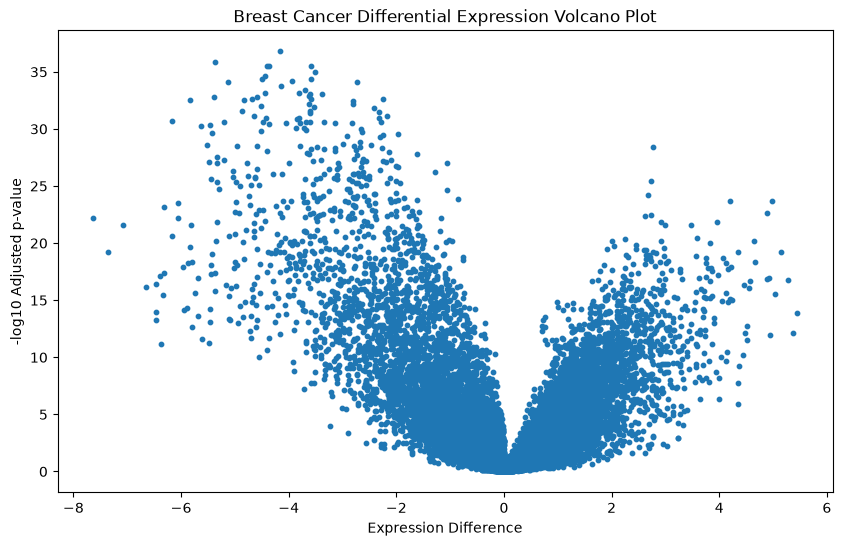

In [57]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.scatter(
    volcano_data["difference"],
    volcano_data["-log10_p"],
    s=10
)

plt.xlabel("Expression Difference")
plt.ylabel("-log10 Adjusted p-value")
plt.title("Breast Cancer Differential Expression Volcano Plot")

plt.show()

In [58]:
volcano_data["significance"] = "Not significant"

volcano_data.loc[
    (volcano_data["adjusted_p_value"] < 0.05) &
    (volcano_data["difference"] > 1),
    "significance"
] = "Upregulated"


volcano_data.loc[
    (volcano_data["adjusted_p_value"] < 0.05) &
    (volcano_data["difference"] < -1),
    "significance"
] = "Downregulated"


volcano_data["significance"].value_counts()

significance
Not significant    48111
Upregulated         3384
Downregulated       3084
Name: count, dtype: int64

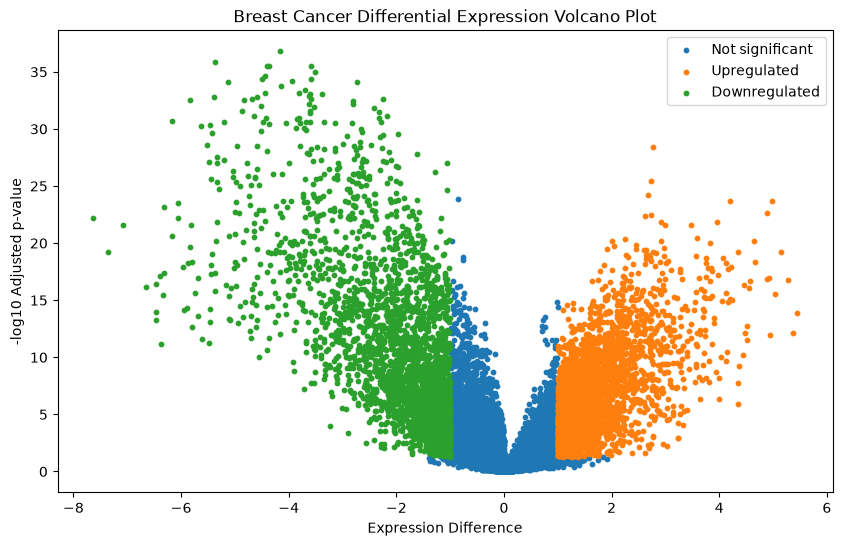

In [60]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))


for category in [
    "Not significant",
    "Upregulated",
    "Downregulated"
]:

    subset = volcano_data[
        volcano_data["significance"] == category
    ]

    plt.scatter(
        subset["difference"],
        subset["-log10_p"],
        label=category,
        s=10
    )


plt.xlabel("Expression Difference")
plt.ylabel("-log10 Adjusted p-value")
plt.title(
    "Breast Cancer Differential Expression Volcano Plot"
)

plt.legend()

plt.show()

In [61]:
plt.savefig(
    "../results/figures/volcano_plot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [63]:
expression_matrix.shape

(54675, 121)

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# transpose
pca_data = expression_matrix.T

pca_data.shape

(121, 54675)

In [65]:
scaler = StandardScaler()

pca_scaled = scaler.fit_transform(pca_data)

pca_scaled.shape

(121, 54675)

In [66]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    pca_scaled
)

principal_components.shape

(121, 2)

In [67]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    pca_scaled
)

principal_components.shape

(121, 2)

In [69]:
metadata = pd.DataFrame(
    [
        sample.metadata 
        for sample in gse.gsms.values()
    ],
    index=gse.gsms.keys()
)

metadata.head()

,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,contact_email,contact_department,contact_institute,contact_address,contact_city,contact_zip/postal_code,contact_country,supplementary_file,series_id,data_row_count
GSM1045191,"[Normal breast, N1_15_12_04]",[GSM1045191],[Public on May 26 2013],[Nov 27 2012],[Jul 30 2013],[RNA],[1],"[Breast tissue, normal]",[Homo sapiens],[9606],...,[colin.clarke@dcu.ie],[NICB],[Dublin City University],[Collin's Av.],[Dublin],[Dublin 9],[Ireland],[ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM104...,[GSE42568],[54675]
GSM1045192,"[Normal breast, N4_14_12_04]",[GSM1045192],[Public on May 26 2013],[Nov 27 2012],[Jul 30 2013],[RNA],[1],"[Breast tissue, normal]",[Homo sapiens],[9606],...,[colin.clarke@dcu.ie],[NICB],[Dublin City University],[Collin's Av.],[Dublin],[Dublin 9],[Ireland],[ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM104...,[GSE42568],[54675]
GSM1045193,"[Normal breast, N5_15_12_04]",[GSM1045193],[Public on May 26 2013],[Nov 27 2012],[Jul 30 2013],[RNA],[1],"[Breast tissue, normal]",[Homo sapiens],[9606],...,[colin.clarke@dcu.ie],[NICB],[Dublin City University],[Collin's Av.],[Dublin],[Dublin 9],[Ireland],[ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM104...,[GSE42568],[54675]
GSM1045194,"[Normal breast, N6_14_12_04]",[GSM1045194],[Public on May 26 2013],[Nov 27 2012],[Jul 30 2013],[RNA],[1],"[Breast tissue, normal]",[Homo sapiens],[9606],...,[colin.clarke@dcu.ie],[NICB],[Dublin City University],[Collin's Av.],[Dublin],[Dublin 9],[Ireland],[ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM104...,[GSE42568],[54675]
GSM1045195,"[Normal breast, P1_15_12_04]",[GSM1045195],[Public on May 26 2013],[Nov 27 2012],[Jul 30 2013],[RNA],[1],"[Breast tissue, normal]",[Homo sapiens],[9606],...,[colin.clarke@dcu.ie],[NICB],[Dublin City University],[Collin's Av.],[Dublin],[Dublin 9],[Ireland],[ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM104...,[GSE42568],[54675]


In [70]:
sample_labels = metadata["source_name_ch1"]

sample_labels.value_counts()

source_name_ch1
[Breast tissue, cancer]    104
[Breast tissue, normal]     17
Name: count, dtype: int64

In [71]:
metadata = metadata.loc[expression_matrix.columns]

In [72]:
sample_labels = metadata["source_name_ch1"]

sample_labels.value_counts()

source_name_ch1
[Breast tissue, cancer]    104
[Breast tissue, normal]     17
Name: count, dtype: int64

In [74]:
principal_components.shape

(121, 2)

In [75]:
import pandas as pd

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-55.748104,117.548511
1,188.902855,117.196353
2,273.652982,84.605604
3,185.360522,71.988442
4,-67.920435,147.453093


In [76]:
pca_df["group"] = sample_labels.values

pca_df.head()

,PC1,PC2,group
0,-55.748104,117.548511,"[Breast tissue, normal]"
1,188.902855,117.196353,"[Breast tissue, normal]"
2,273.652982,84.605604,"[Breast tissue, normal]"
3,185.360522,71.988442,"[Breast tissue, normal]"
4,-67.920435,147.453093,"[Breast tissue, normal]"


In [78]:
sample_labels = metadata["source_name_ch1"].apply(lambda x: x[0])

sample_labels.value_counts()

source_name_ch1
Breast tissue, cancer    104
Breast tissue, normal     17
Name: count, dtype: int64

In [79]:
pca_df["group"] = sample_labels.values

pca_df.head()

,PC1,PC2,group
0,-55.748104,117.548511,"Breast tissue, normal"
1,188.902855,117.196353,"Breast tissue, normal"
2,273.652982,84.605604,"Breast tissue, normal"
3,185.360522,71.988442,"Breast tissue, normal"
4,-67.920435,147.453093,"Breast tissue, normal"


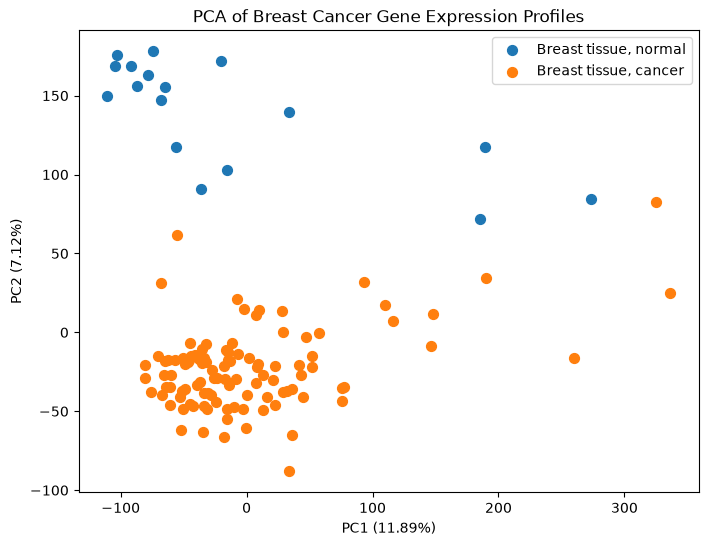

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for group in pca_df["group"].unique():

    subset = pca_df[
        pca_df["group"] == group
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        s=50
    )


plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)

plt.title(
    "PCA of Breast Cancer Gene Expression Profiles"
)

plt.legend()
plt.show()

In [81]:
plt.savefig(
    "../results/figures/PCA_plot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [82]:
significant_annotated.shape

(6468, 11)

In [83]:
top_genes = significant_annotated.sort_values(
    by="adjusted_p_value"
).head(50)

top_genes[["Gene Symbol","difference","adjusted_p_value"]].head(10)

,Gene Symbol,difference,adjusted_p_value
5730,LOC284825,-4.156655,1.652110e-37
2728,FHL1,-5.373465,1.332436e-36
6462,ACSM5,-4.365654,2.865693e-36
5108,PGM5-AS1,-3.582643,3.074328e-36
2732,PDE3B,-4.409098,3.074328e-36
3834,NIPSNAP3B,-3.506073,1.016612e-35
3198,LYVE1,-4.443315,2.226148e-35
5545,STX11,-3.589670,3.980362e-35
1649,GLYAT,-4.488150,4.173674e-35
3457,CIDEA,-3.930097,6.169170e-35


In [85]:
top_genes = significant_annotated.sort_values(
    by="adjusted_p_value"
).head(50)

top_genes[["Gene Symbol","difference","adjusted_p_value"]].head(10)

,Gene Symbol,difference,adjusted_p_value
5730,LOC284825,-4.156655,1.652110e-37
2728,FHL1,-5.373465,1.332436e-36
6462,ACSM5,-4.365654,2.865693e-36
5108,PGM5-AS1,-3.582643,3.074328e-36
2732,PDE3B,-4.409098,3.074328e-36
3834,NIPSNAP3B,-3.506073,1.016612e-35
3198,LYVE1,-4.443315,2.226148e-35
5545,STX11,-3.589670,3.980362e-35
1649,GLYAT,-4.488150,4.173674e-35
3457,CIDEA,-3.930097,6.169170e-35


In [86]:
top_gene_ids = top_genes["ID_REF"]

top_gene_ids.head()

5730      237351_at
2728    214505_s_at
6462       89977_at
5108      230595_at
2732      214582_at
Name: ID_REF, dtype: str

In [87]:
heatmap_data = expression_matrix.loc[top_gene_ids]

heatmap_data.head()

sample_id,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,GSM1045200,...,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
ID_REF,,,,,,,,,,,,,,,,,,,,,
237351_at,6.365318,2.312812,2.662790,3.488320,7.188542,7.962346,7.738890,7.628550,7.674282,6.419993,...,2.312812,2.312835,2.312812,2.312812,2.312812,2.725510,2.312812,2.312812,2.312812,2.312812
214505_s_at,10.097525,5.059265,4.932825,4.458826,10.620089,9.665313,11.134826,9.731045,10.299750,8.160006,...,3.982358,3.475284,3.145577,3.475284,3.475284,3.815990,2.903734,4.510101,3.586291,3.475284
89977_at,7.360662,3.837614,2.961464,2.774986,8.190584,8.335032,8.234784,7.851820,8.032401,6.604763,...,2.350182,2.350182,2.350643,2.342277,2.353353,2.398923,2.350182,3.352261,2.350182,2.350182
230595_at,5.539122,2.312812,2.327013,3.493844,6.596741,7.367654,7.157238,6.964371,7.202969,7.077492,...,2.327013,2.531632,2.327013,2.327013,2.327013,2.327013,2.327013,2.327013,2.327013,2.371131
214582_at,7.411974,3.841513,3.694542,2.312812,7.452230,8.852127,7.977533,7.860528,8.362353,5.851034,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.598907,2.312812,2.336507,2.312812,2.312812


In [88]:
gene_labels = top_genes["Gene Symbol"].values

gene_labels[:10]

<StringArray>
['LOC284825',      'FHL1',     'ACSM5',  'PGM5-AS1',     'PDE3B', 'NIPSNAP3B',
     'LYVE1',     'STX11',     'GLYAT',     'CIDEA']
Length: 10, dtype: str

In [89]:
heatmap_data.index = gene_labels

heatmap_data.head()

sample_id,GSM1045191,GSM1045192,GSM1045193,GSM1045194,GSM1045195,GSM1045196,GSM1045197,GSM1045198,GSM1045199,GSM1045200,...,GSM1045302,GSM1045303,GSM1045304,GSM1045305,GSM1045306,GSM1045307,GSM1045308,GSM1045309,GSM1045310,GSM1045311
LOC284825,6.365318,2.312812,2.662790,3.488320,7.188542,7.962346,7.738890,7.628550,7.674282,6.419993,...,2.312812,2.312835,2.312812,2.312812,2.312812,2.725510,2.312812,2.312812,2.312812,2.312812
FHL1,10.097525,5.059265,4.932825,4.458826,10.620089,9.665313,11.134826,9.731045,10.299750,8.160006,...,3.982358,3.475284,3.145577,3.475284,3.475284,3.815990,2.903734,4.510101,3.586291,3.475284
ACSM5,7.360662,3.837614,2.961464,2.774986,8.190584,8.335032,8.234784,7.851820,8.032401,6.604763,...,2.350182,2.350182,2.350643,2.342277,2.353353,2.398923,2.350182,3.352261,2.350182,2.350182
PGM5-AS1,5.539122,2.312812,2.327013,3.493844,6.596741,7.367654,7.157238,6.964371,7.202969,7.077492,...,2.327013,2.531632,2.327013,2.327013,2.327013,2.327013,2.327013,2.327013,2.327013,2.371131
PDE3B,7.411974,3.841513,3.694542,2.312812,7.452230,8.852127,7.977533,7.860528,8.362353,5.851034,...,2.312812,2.312812,2.312812,2.312812,2.312812,2.598907,2.312812,2.336507,2.312812,2.312812


In [96]:
annotated_results.head()

,normal_mean,cancer_mean,difference,p_value,adjusted_p_value,ID,Gene Symbol,Gene Title,Gene Ontology Biological Process,Gene Ontology Molecular Function
0,5.143417,7.521487,2.378070,1.054656e-14,4.380676e-13,1007_s_at,DDR1 /// MIR4640,discoidin domain receptor tyrosine kinase 1 //...,0001558 // regulation of cell growth // inferr...,0000166 // nucleotide binding // inferred from...
1,5.491319,5.686114,0.194795,3.413857e-01,5.336529e-01,1053_at,RFC2,"replication factor C (activator 1) 2, 40kDa",0000278 // mitotic cell cycle // traceable aut...,0000166 // nucleotide binding // inferred from...
2,4.215687,4.478162,0.262474,1.749951e-01,3.343506e-01,117_at,HSPA6,heat shock 70kDa protein 6 (HSP70B'),0000902 // cell morphogenesis // inferred from...,0000166 // nucleotide binding // inferred from...
3,3.721981,3.669668,-0.052313,5.750617e-01,7.330506e-01,121_at,PAX8,paired box 8,0001655 // urogenital system development // in...,0000979 // RNA polymerase II core promoter seq...
4,2.320657,2.315915,-0.004742,3.953547e-01,5.868069e-01,1255_g_at,GUCA1A,guanylate cyclase activator 1A (retina),0007165 // signal transduction // non-traceabl...,0005509 // calcium ion binding // inferred fro...


In [97]:
# --------------------------------
# 4. Get actual probe IDs
# --------------------------------

top_gene_ids = top_genes["ID"]


print("Example probes:")
print(top_gene_ids.head())

Example probes:
46515      237351_at
23748    214505_s_at
54505       89977_at
39772      230595_at
23824      214582_at
Name: ID, dtype: str


In [98]:
# --------------------------------
# 5. Extract expression values
# --------------------------------

heatmap_data = expression_matrix.loc[
    top_gene_ids
]


print(
    heatmap_data.shape
)

(40, 121)


In [99]:
# --------------------------------
# 6. Replace probe names with genes
# --------------------------------

heatmap_data.index = (
    top_genes["Gene Symbol"]
    .values
)


# Remove duplicate gene names

heatmap_data = heatmap_data[
    ~heatmap_data.index.duplicated(
        keep="first"
    )
]


print(
    heatmap_data.shape
)

(40, 121)


In [ ]:
results["p_value"].isna().sum()

np.int64(96)

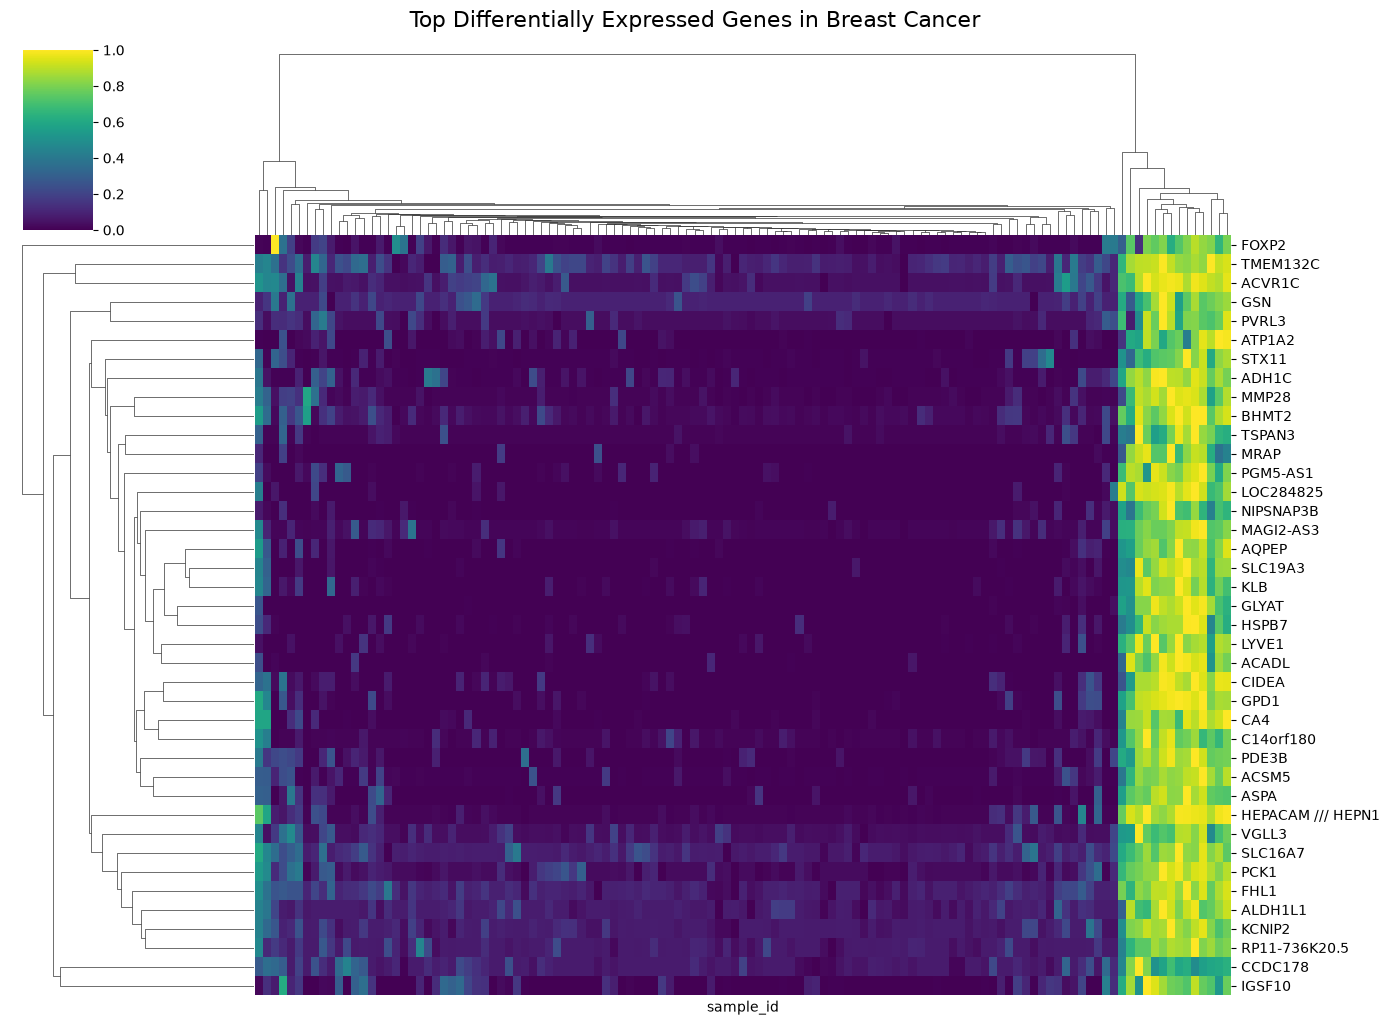

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt


cluster = sns.clustermap(
    heatmap_data,
    cmap="viridis",
    standard_scale=0,
    figsize=(14,10),
    xticklabels=False,
    yticklabels=True
)


plt.suptitle(
    "Top Differentially Expressed Genes in Breast Cancer",
    y=1.02,
    fontsize=16
)


plt.show()

In [101]:
cluster.savefig(
    "../results/figures/heatmap_clustered.png",
    dpi=300,
    bbox_inches="tight"
)

In [103]:
!pip install gseapy

   ---------------------------------------- 0.0/505.3 kB ? eta -:--:--
    --------------------------------------- 10.2/505.3 kB ? eta -:--:--
   ----------- ---------------------------- 143.4/505.3 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 505.3/505.3 kB 5.3 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
import gseapy as gp


# Significant genes only
sig_genes = annotated_results[
    annotated_results["adjusted_p_value"] < 0.05
]


# Upregulated
up_genes = sig_genes[
    sig_genes["difference"] > 0
]["Gene Symbol"]


# Downregulated
down_genes = sig_genes[
    sig_genes["difference"] < 0
]["Gene Symbol"]


# Clean gene symbols
up_genes = (
    up_genes
    .str.split(" /// ")
    .str[0]
    .dropna()
    .tolist()
)


down_genes = (
    down_genes
    .str.split(" /// ")
    .str[0]
    .dropna()
    .tolist()
)


print("Upregulated genes:", len(up_genes))
print("Downregulated genes:", len(down_genes))

Upregulated genes: 6881
Downregulated genes: 7943


In [106]:
print(len(up_genes))
print(len(down_genes))

6881
7943


In [107]:
sig_genes.shape

(17028, 10)

In [108]:
sig_genes[["difference","adjusted_p_value"]].head()

,difference,adjusted_p_value
0,2.378070,4.380676e-13
7,-0.127529,7.164705e-03
14,1.474300,4.789155e-06
24,-0.604409,5.351383e-03
33,1.390712,1.222818e-07


In [109]:
# Significant genes only

sig_genes = annotated_results[
    (annotated_results["adjusted_p_value"] < 0.05)
].copy()


print(
    "Significant genes:",
    sig_genes.shape
)

Significant genes: (17028, 10)


In [110]:
# Upregulated

up_genes = (
    sig_genes[
        sig_genes["difference"] > 0
    ]["Gene Symbol"]
    .dropna()
    .str.split(" /// ")
    .str[0]
    .unique()
    .tolist()
)


# Downregulated

down_genes = (
    sig_genes[
        sig_genes["difference"] < 0
    ]["Gene Symbol"]
    .dropna()
    .str.split(" /// ")
    .str[0]
    .unique()
    .tolist()
)


print("Upregulated:", len(up_genes))
print("Downregulated:", len(down_genes))

Upregulated: 4876
Downregulated: 5402


In [111]:
go_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human"
)

go_up_results = go_up.results

go_up_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Chromatin Remodeling (GO:0006338),103/228,4.654034e-12,2.257672e-08,0,0,2.589394,67.565792,FOXA1;SMARCB1;KDM1A;PWWP2B;YEATS4;RUVBL2;CHEK1...
1,GO_Biological_Process_2023,DNA Metabolic Process (GO:0006259),122/288,1.158526e-11,2.707395e-08,0,0,2.312417,58.229629,SMARCB1;DCLRE1C;TRRAP;ENDOV;HELB;TRIM28;RUVBL2...
2,GO_Biological_Process_2023,Chromatin Organization (GO:0006325),115/268,1.674332e-11,2.707395e-08,0,0,2.363519,58.646040,FOXA1;SMARCB1;PWWP2B;EHMT1;HNRNPU;NUCKS1;YEATS...
3,GO_Biological_Process_2023,RNA Processing (GO:0006396),81/183,2.803623e-09,3.400094e-06,0,0,2.487849,48.991599,TCERG1;FASTKD1;CELF1;AKAP8L;HNRNPU;HNRNPR;ADAR...
4,GO_Biological_Process_2023,Regulation Of DNA-templated Transcription (GO:...,571/1922,1.159458e-08,1.124906e-05,0,0,1.352185,24.708111,ZNF296;EHF;TRRAP;ZNF292;EHMT1;ELK1;ZMIZ1;CREB3...


In [112]:
import os

os.makedirs(
    "../results/enrichment",
    exist_ok=True
)


go_up_results.to_csv(
    "../results/enrichment/GO_upregulated.csv",
    index=False
)

In [113]:
go_down = gp.enrichr(
    gene_list=down_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human"
)


go_down_results = go_down.results


go_down_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Cellular Respiration (GO:0045333),48/85,9.468380e-09,0.000048,0,0,3.528193,65.184455,COX7B;NDUFB8;NDUFA11;NDUFB6;UQCRB;NDUFA12;COX1...
1,GO_Biological_Process_2023,Regulation Of Focal Adhesion Assembly (GO:0051...,34/54,3.347273e-08,0.000085,0,0,4.616729,79.465605,ACVRL1;MACF1;ROCK1;ROCK2;FAM107A;PTEN;EFNA5;AR...
2,GO_Biological_Process_2023,Aerobic Electron Transport Chain (GO:0019646),38/68,4.666347e-07,0.000794,0,0,3.440119,50.149093,COX7B;NDUFB8;NDUFB6;UQCRB;COX15;NDUFB5;COX4I1;...
3,GO_Biological_Process_2023,Fatty Acid Oxidation (GO:0019395),31/52,7.784247e-07,0.000993,0,0,4.006410,56.354138,ABCD4;ABCD2;ACAA2;ECHS1;ECI2;HSD17B4;ADH7;ADIP...
4,GO_Biological_Process_2023,Mitochondrial ATP Synthesis Coupled Electron T...,38/70,1.245034e-06,0.001270,0,0,3.224669,43.843723,COX7B;NDUFB8;NDUFB6;UQCRB;NDUFA12;COX15;NDUFB5...


In [114]:
go_down_results.to_csv(
    "../results/enrichment/GO_downregulated.csv",
    index=False
)

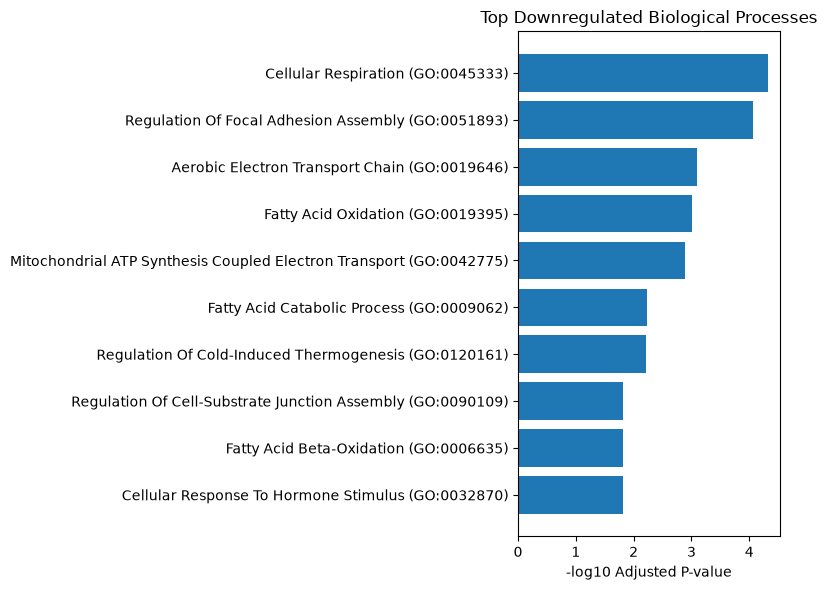

In [115]:
import matplotlib.pyplot as plt


top_down = go_down_results.head(10).copy()


plt.figure(figsize=(8,6))

plt.barh(
    top_down["Term"],
    -__import__("numpy").log10(
        top_down["Adjusted P-value"]
    )
)

plt.xlabel("-log10 Adjusted P-value")

plt.title(
    "Top Downregulated Biological Processes"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/enrichment/downregulated_GO_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

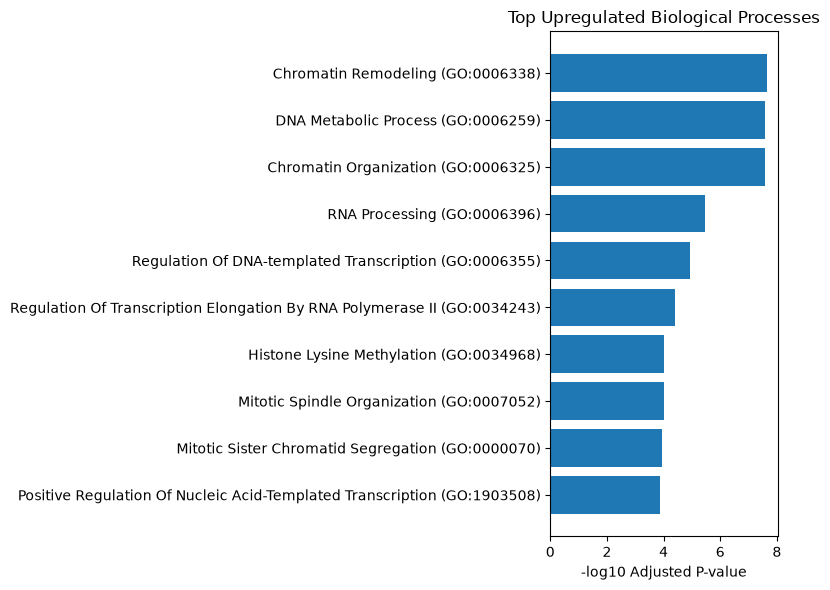

In [116]:
top_up = go_up_results.head(10).copy()


plt.figure(figsize=(8,6))

plt.barh(
    top_up["Term"],
    -__import__("numpy").log10(
        top_up["Adjusted P-value"]
    )
)

plt.xlabel("-log10 Adjusted P-value")

plt.title(
    "Top Upregulated Biological Processes"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../results/enrichment/upregulated_GO_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()